# Performance Analysis and Validation of Power Amplifier (PA) Performance in Relation to the IQ Modulator (IQM)

In [ ]:
import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

## Defining the Power Amplifier (PA) Functions

In [ ]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform in volts.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """
    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """
    wn = f3dB / (Fs / 2)

    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    b, a = signal.butter(order, wn, btype='low')

    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    return y_i + 1j * y_q


def pa_model_physical(x, Fs, gain_linear, BLPF_enable, BO_dB=5.0, p=2.0, f3dB=10e9, order=3):
    """
    Physical PA model:
        x -> linear gain -> Rapp compression -> Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform (dimensionless DSP waveform).
    Fs : float
        Sample rate [Hz].
    gain_linear : float
        Small-signal linear voltage gain. This sets the nominal IQM drive level.
    BO_dB : float
        Back-off in dB, used to set Vsat relative to the RMS value AFTER gain.
    p : float
        Rapp exponent.
    f3dB : float
        PA 3-dB bandwidth [Hz].
    order : int
        Butterworth filter order.

    Returns
    -------
    y : np.ndarray
        PA output waveform in volts, ready to drive the IQM.
    info : dict
        Diagnostic information.
    """

    # 1) Linear gain stage -> now waveform is in volts
    x_amp = gain_linear * x

    # 2) Compute RMS after gain
    Vrms_in = np.sqrt(np.mean(np.abs(x_amp) ** 2))

    # 3) Saturation voltage from back-off
    Vsat = Vrms_in * 10 ** (BO_dB / 20)

    # 4) Nonlinear compression
    y_nl = rapp_pa(x_amp, Vsat=Vsat, p=p)

    # 5) PA bandwidth limitation
    if BLPF_enable:
        y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=order)
    else:
        y = y_nl

    info = {
        "gain_linear": gain_linear,
        "Vrms_in_V": Vrms_in,
        "Vsat_V": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB,
        "peak_out_V": np.max(np.abs(y)),
        "rms_out_V": np.sqrt(np.mean(np.abs(y) ** 2)),
    }

    return y, info

## Optical System Parameter Configuration

In [ ]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QAM -> M=16, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 1           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 0       # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.dist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2

# 5) Optical Carrier / LO field (Ein)
sigTx_length = paramSymb.nSymbols * SpS
if laserLinewidth and laserLinewidth > 0:
    phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=123)
    sigLO = np.exp(1j * phi_pn)
else:
    sigLO = np.ones(sigTx_length, dtype=complex)

# 6) PA parameters 
PA_enable = True    # enable flag. If "False", the PA is skipped
PA_BO_dB = 5        # 7 = weak, 5 = moderate, 3 = strong
PA_p = 2.0           # paper says typically p=2
PA_f3dB = 18.5e9     # frequency of 3 dB
BLPF_enable = True

# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) local oscillator (LO) parameters:
FO  = 0                # frequency offset
paramLO = parameters()
paramLO.P = 10              # power in dBm
paramLO.lw = 0         # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

# 2) Front-End Parameters and photodiode paramters

# Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs

# Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011

# 3) Pulseshaping in the reciever using rrc filter
paramRxPulse = parameters()
paramRxPulse.SpS = SpS
paramRxPulse.nFilterTaps = nFilterTaps
paramRxPulse.rollOff = rollOff
paramRxPulse.pulseType = "rrc"

# 4) Decimation Parameters
paramDec = parameters()
paramDec.SpSin  = SpS
paramDec.SpSout = 1

In [ ]:
def simulate_optical_system(symbTx, paramSymb, paramPulse, paramIQM, sigLO, paramLO, paramFE, paramPD, paramRxPulse, paramDec, mzmScale, BLPF_enable):

    """
    Simulates the optical transmission of a single-polarization, single-channel QAM signal.

    Returns
    -------
    u_drive :
        Electrical PA output in volts applied directly to the IQM
    sigTx :
        Pulse-shaped DSP waveform before PA
    sigTxo :
        Optical transmitted signal
    sigRxPulseShape :
        Received signal after matched filtering
    sigRxDecimation :
        Received signal after decimation
    paInfo :
        PA diagnostics
    """

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 1) Upsampling + pulse shaping
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # 2) Choose nominal small-signal PA gain so the nominal drive is around mzmScale * Vpi
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))

    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero; cannot set PA gain.")

    gain_linear = target_peak_V / peak_sigTx

    # 3) Driver amplifier / PA output directly in volts
    if PA_enable:
        u_drive, paInfo = pa_model_physical(
            sigTx,
            Fs=Fs,
            gain_linear=gain_linear,
            BLPF_enable = BLPF_enable,
            BO_dB=PA_BO_dB,
            p=PA_p,
            f3dB=PA_f3dB,
            order=3
        )
    else:
        u_drive = gain_linear * sigTx
        paInfo = {
            "gain_linear": gain_linear,
            "Vrms_in_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
            "Vsat_V": None,
            "BO_dB": None,
            "p": None,
            "f3dB_Hz": None,
            "peak_out_V": np.max(np.abs(u_drive)),
            "rms_out_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
        }

    # 4) IQ modulation: PA output drives the IQM directly
    sigTxo = iqm(sigLO, u_drive, paramIQM)

    # 5) Set launched optical power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    paramLO.Ns = len(sigTxo)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent receiver
    sigRxFrontEnd = coherentReceiver(sigTxo, sigLO_Rx, paramFE, paramPD)

    # 3) Matched filtering
    pulse = pulseShape(paramRxPulse)
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # 4) Decimation
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    return u_drive, sigTx, sigTxo, sigRxPulseShape, sigRxDecimation, paInfo

## Plot Functions to Explore and Validate Performance

In [ ]:
# Plotting functions for the IQM

def plot_mzm_transfer_function_and_operating_range_of_drive_signal(u_drive):
    
    v_axis = np.linspace(-4*paramIQM.Vpi, 4*paramIQM.Vpi, 2000)
    transfer = np.cos((np.pi/(2*paramIQM.Vpi)) * v_axis)

    plt.figure(figsize=(9,4))

    plt.plot(v_axis/paramIQM.Vpi, transfer, label='MZM field transfer')
    
    plt.axvspan(np.min(u_drive.real + paramIQM.VbI)/paramIQM.Vpi, np.max(u_drive.real + paramIQM.VbI)/paramIQM.Vpi, alpha=0.25, label='I-arm operating range')
    plt.axvspan(np.min(u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi, np.max(u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi, alpha=0.25, label='Q-arm operating range')

    plt.axvline(paramIQM.VbI/paramIQM.Vpi,color='red', linestyle='--', linewidth=2, label='Bias point')
    plt.xlabel(r'Total branch voltage / $V_\pi$')
    plt.ylabel('Field transfer')
    plt.title('Where the drive signal operates on the MZM transfer curve')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def plot_histogram_of_IQM_branches(u_drive):  

    xI = (u_drive.real + paramIQM.VbI)/paramIQM.Vpi
    xQ = (u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(xI, bins=100, density=True)
    plt.title("I branch normalized voltage")
    plt.xlabel("(uI+VbI)/Vpi")

    plt.subplot(1,2,2)
    plt.hist(xQ, bins=100, density=True)
    plt.title("Q branch normalized voltage")
    plt.xlabel("(uQ+VbQ)/Vpi")

    plt.tight_layout()
    plt.show()

def EVM_vs_mzmScale_plot(mzmScale_list, EVM_list):
    plt.figure(figsize=(7,4))
    plt.plot(mzmScale_list, np.array(EVM_list)*100, 'o-', linewidth=2)
    plt.xlabel('mzmScale')
    plt.ylabel('EVM [%]')
    plt.title('Tx-side EVM vs IQM modulation depth')
    plt.grid(True)
    plt.tight_layout()
    plt.show()  

def plot_am_am(u_drive, sigTx, sigTxo, PA_enable):
    if PA_enable:
        amp_in = np.abs(u_drive)
        amp_out = np.abs(sigTxo)
    else:
        amp_in = np.abs(sigTx)
        amp_out = np.abs(sigTxo)

    plt.figure(figsize=(6,5))
    plt.scatter(amp_in, amp_out, s=2, alpha=0.3)
    plt.xlabel("Input amplitude |s(t)|")
    plt.ylabel("Output optical amplitude |E(t)|")
    plt.title("AM-AM distortion (Tx nonlinearity)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Function to Print Metrics for Performance Evaluation

In [ ]:
def print_tx_metrics(sigTx, u_drive, sigTxo, paramIQM, mzmScale, EVM, paInfo=None):
    """
    Minimal Tx-side validation metrics for the IQM transmitter.
    """

    print("\n===== TX VALIDATION =====\n")

    peak_sigTx = np.max(np.abs(sigTx))
    rms_sigTx = np.sqrt(np.mean(np.abs(sigTx)**2))

    print(f"Peak |sigTx| before PA    : {peak_sigTx:.6f}")
    print(f"RMS  |sigTx| before PA    : {rms_sigTx:.6f}")

    target_peak_V = mzmScale * paramIQM.Vpi
    peak_rf_drive = np.max(np.abs(u_drive)) / paramIQM.Vpi

    print(f"Nominal target peak [V]   : {target_peak_V:.3f}")
    print(f"Actual peak |u_drive| [V] : {np.max(np.abs(u_drive)):.3f}")
    print(f"Peak RF drive / Vpi       : {peak_rf_drive:.3f}")

    vI_norm = (u_drive.real + paramIQM.VbI) / paramIQM.Vpi
    vQ_norm = (u_drive.imag + paramIQM.VbQ) / paramIQM.Vpi

    print(f"I voltage range / Vpi     : [{np.min(vI_norm):.3f} , {np.max(vI_norm):.3f}]")
    print(f"Q voltage range / Vpi     : [{np.min(vQ_norm):.3f} , {np.max(vQ_norm):.3f}]")

    max_norm_total = max(np.max(np.abs(vI_norm)), np.max(np.abs(vQ_norm)))
    print(f"Max |(u+Vb)/Vpi|          : {max_norm_total:.3f}")

    opt_power = np.abs(sigTxo) ** 2
    mean_opt_power = np.mean(opt_power)
    print(f"Mean optical power        : {mean_opt_power:.4e}")

    if paInfo is not None:
        print(f"PA gain_linear            : {paInfo['gain_linear']:.4f}")
        if paInfo["BO_dB"] is not None:
            print(f"PA BO_dB                  : {paInfo['BO_dB']:.2f}")
        if paInfo["Vsat_V"] is not None:
            print(f"PA Vsat [V]               : {paInfo['Vsat_V']:.4f}")
        print(f"PA output RMS [V]         : {paInfo['rms_out_V']:.4f}")

    print('EVM                       : %.3f %%' % (EVM[0] * 100))

    print("\n=========================\n")

## EVM Calculation Function

In [ ]:
def evm_calc(symbTx, received):
    discard = 5000
    ind = np.arange(discard, len(symbTx) - discard)
    d = symbTx

    # now compute metrics (both are 1 sample/symbol and same length)
    EVM = calcEVM(received[ind], M, 'qam', d[ind])

    return EVM
   

## Impact of MZM Scale Factor on IQ Modulator (IQM) Nonlinear Distortion via PA Functions

mzmScale Sweep:   0%|          | 0/9 [00:00<?, ?it/s]

True
18500000000.0


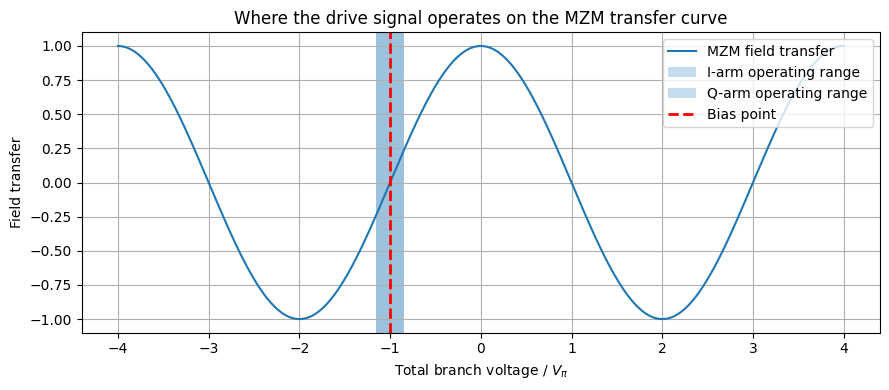

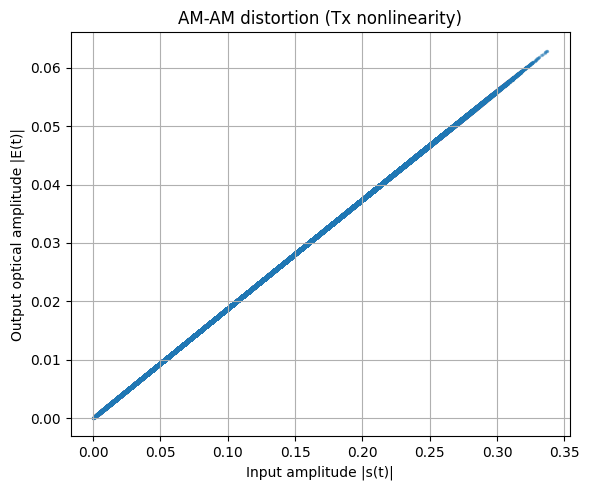

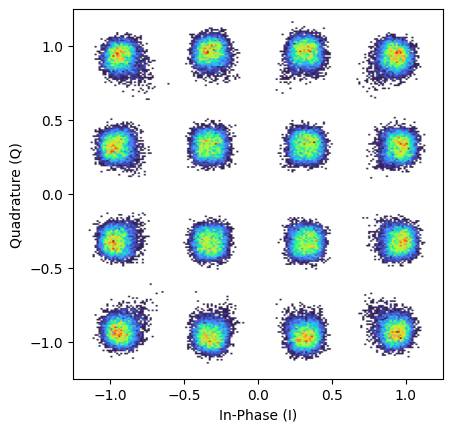


===== TX VALIDATION =====

Peak |sigTx| before PA    : 0.171459
RMS  |sigTx| before PA    : 0.062902
Nominal target peak [V]   : 0.500
Actual peak |u_drive| [V] : 0.337
Peak RF drive / Vpi       : 0.169
I voltage range / Vpi     : [-1.153 , -0.849]
Q voltage range / Vpi     : [-1.153 , -0.851]
Max |(u+Vb)/Vpi|          : 1.153
Mean optical power        : 1.0000e-03
PA gain_linear            : 2.9162
PA BO_dB                  : 5.00
PA Vsat [V]               : 0.3262
PA output RMS [V]         : 0.1689
EVM                       : 0.791 %


True
18500000000.0


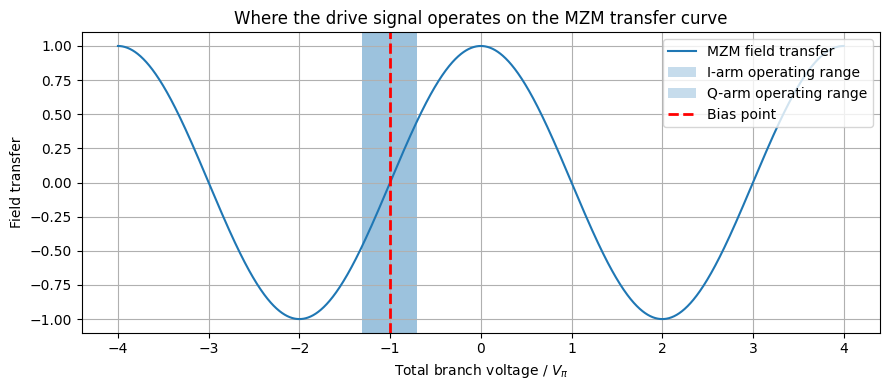

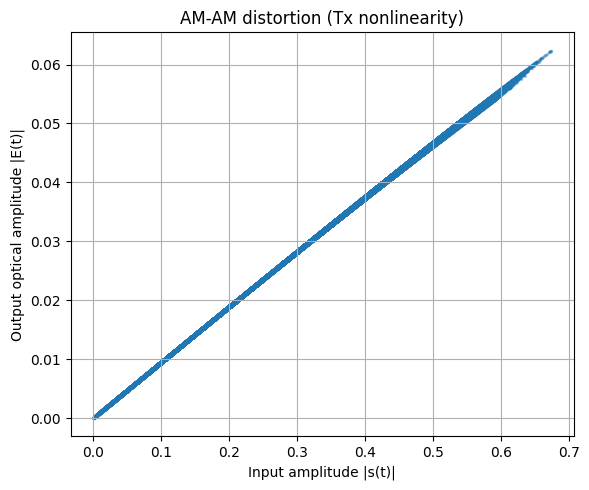

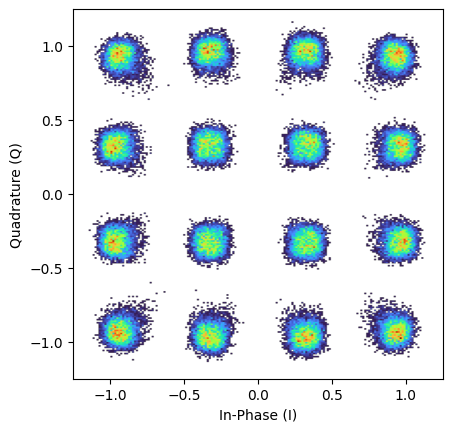


===== TX VALIDATION =====

Peak |sigTx| before PA    : 0.171459
RMS  |sigTx| before PA    : 0.062902
Nominal target peak [V]   : 1.000
Actual peak |u_drive| [V] : 0.674
Peak RF drive / Vpi       : 0.337
I voltage range / Vpi     : [-1.306 , -0.698]
Q voltage range / Vpi     : [-1.306 , -0.701]
Max |(u+Vb)/Vpi|          : 1.306
Mean optical power        : 1.0000e-03
PA gain_linear            : 5.8323
PA BO_dB                  : 5.00
PA Vsat [V]               : 0.6524
PA output RMS [V]         : 0.3377
EVM                       : 0.806 %


True
18500000000.0


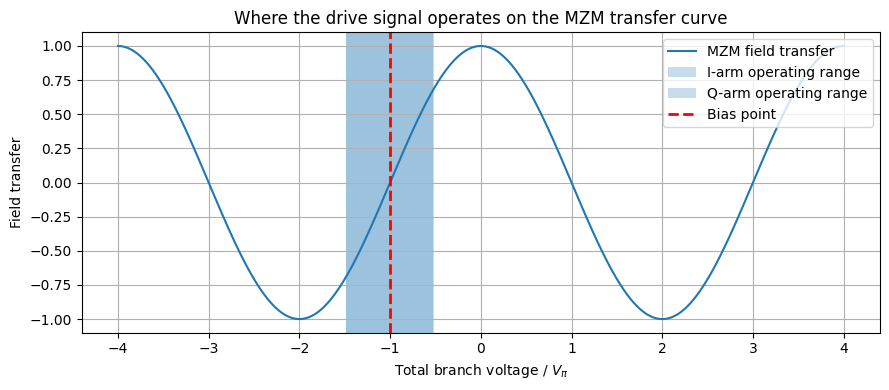

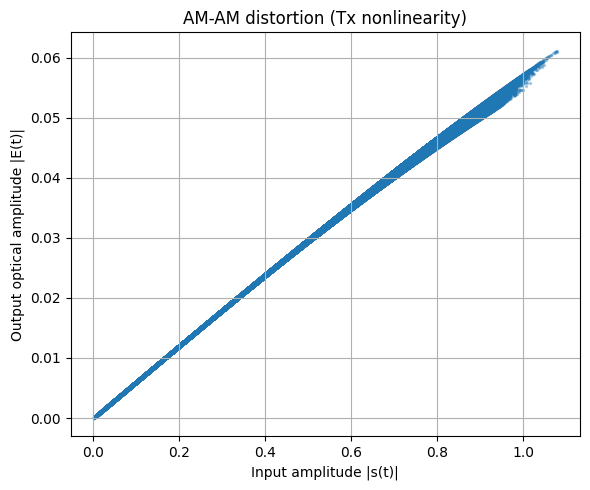

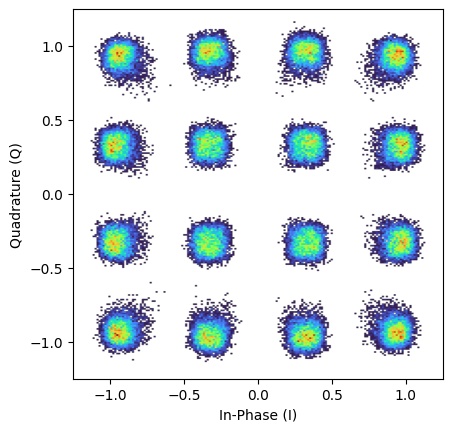


===== TX VALIDATION =====

Peak |sigTx| before PA    : 0.171459
RMS  |sigTx| before PA    : 0.062902
Nominal target peak [V]   : 1.600
Actual peak |u_drive| [V] : 1.078
Peak RF drive / Vpi       : 0.539
I voltage range / Vpi     : [-1.490 , -0.517]
Q voltage range / Vpi     : [-1.490 , -0.522]
Max |(u+Vb)/Vpi|          : 1.490
Mean optical power        : 1.0000e-03
PA gain_linear            : 9.3317
PA BO_dB                  : 5.00
PA Vsat [V]               : 1.0438
PA output RMS [V]         : 0.5404
EVM                       : 0.842 %


True
18500000000.0


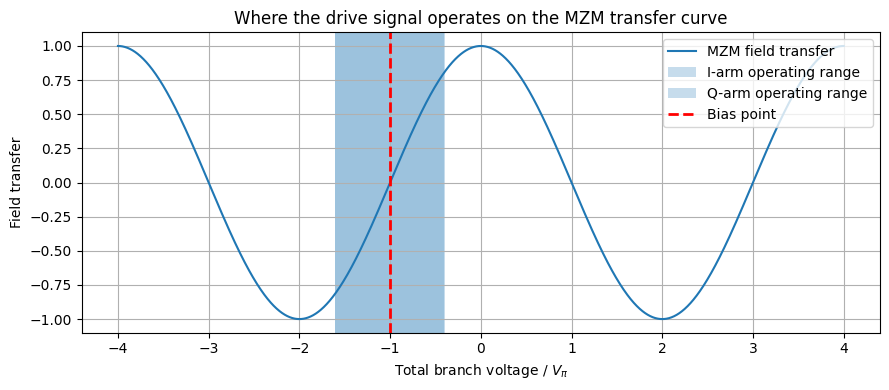

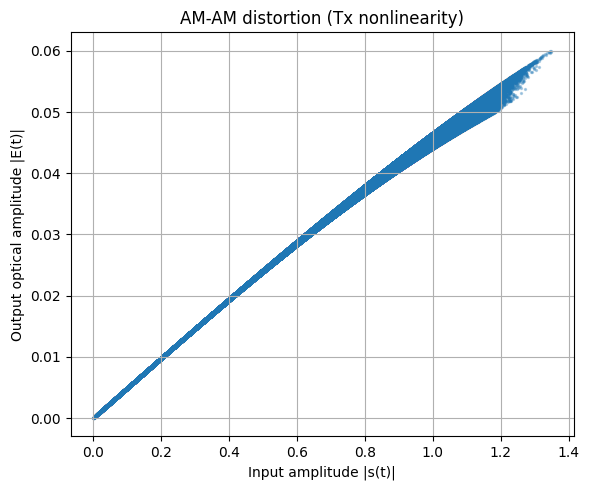

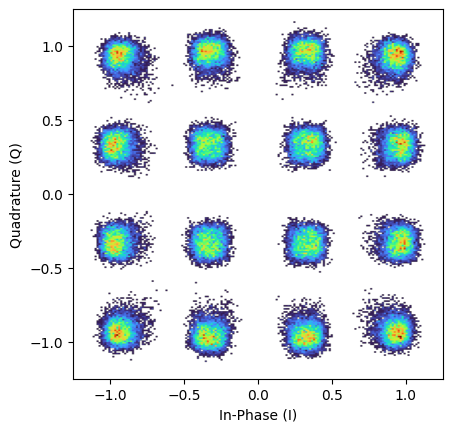


===== TX VALIDATION =====

Peak |sigTx| before PA    : 0.171459
RMS  |sigTx| before PA    : 0.062902
Nominal target peak [V]   : 2.000
Actual peak |u_drive| [V] : 1.348
Peak RF drive / Vpi       : 0.674
I voltage range / Vpi     : [-1.612 , -0.396]
Q voltage range / Vpi     : [-1.613 , -0.403]
Max |(u+Vb)/Vpi|          : 1.613
Mean optical power        : 1.0000e-03
PA gain_linear            : 11.6646
PA BO_dB                  : 5.00
PA Vsat [V]               : 1.3048
PA output RMS [V]         : 0.6755
EVM                       : 0.885 %


True
18500000000.0


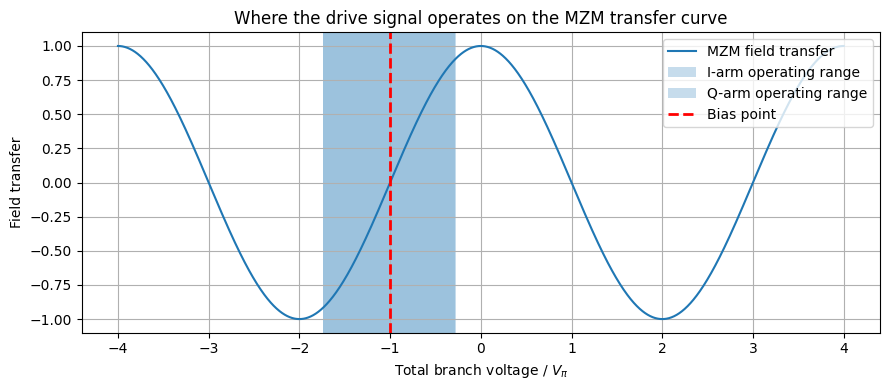

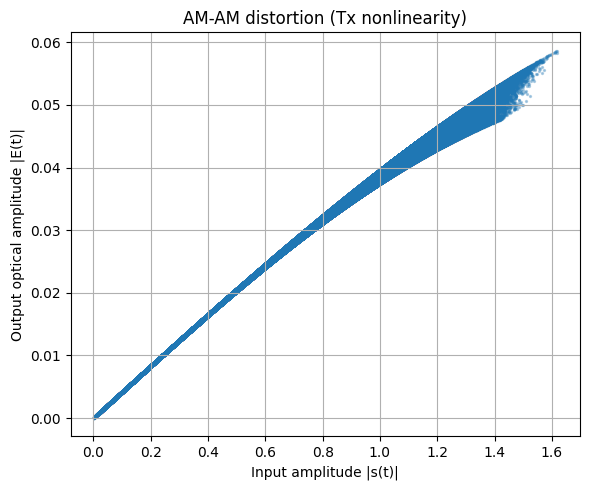

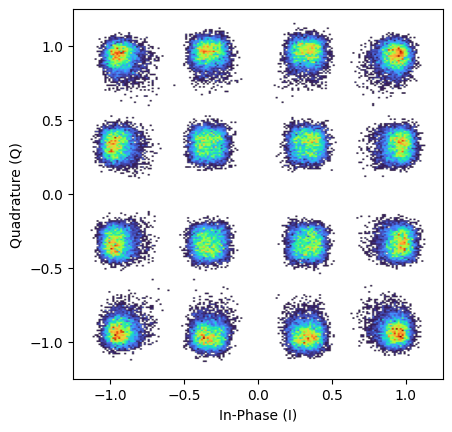


===== TX VALIDATION =====

Peak |sigTx| before PA    : 0.171459
RMS  |sigTx| before PA    : 0.062902
Nominal target peak [V]   : 2.400
Actual peak |u_drive| [V] : 1.618
Peak RF drive / Vpi       : 0.809
I voltage range / Vpi     : [-1.735 , -0.276]
Q voltage range / Vpi     : [-1.735 , -0.283]
Max |(u+Vb)/Vpi|          : 1.735
Mean optical power        : 1.0000e-03
PA gain_linear            : 13.9975
PA BO_dB                  : 5.00
PA Vsat [V]               : 1.5657
PA output RMS [V]         : 0.8106
EVM                       : 0.947 %


True
18500000000.0


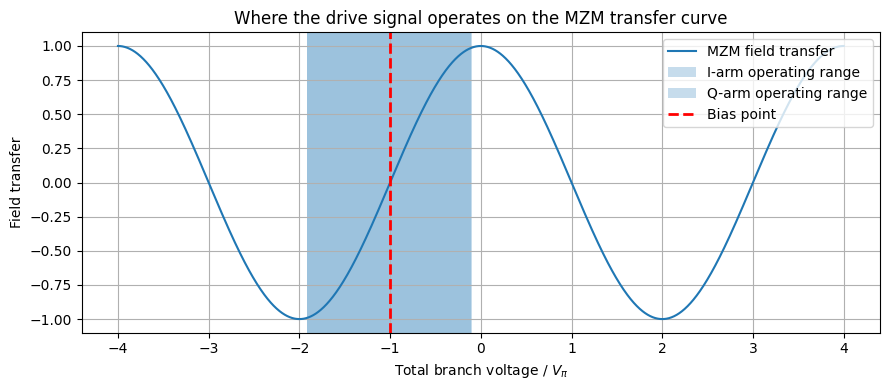

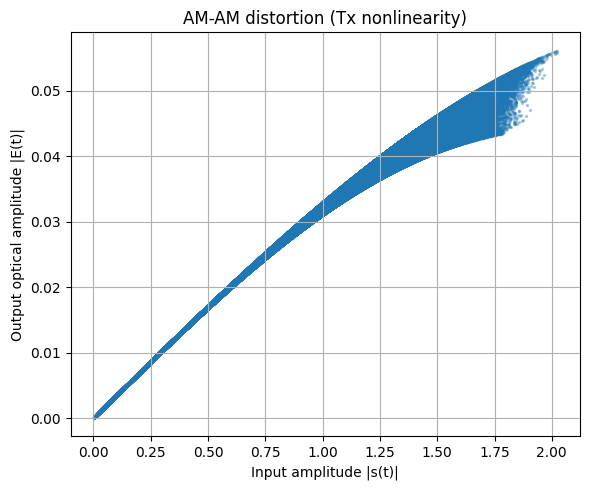

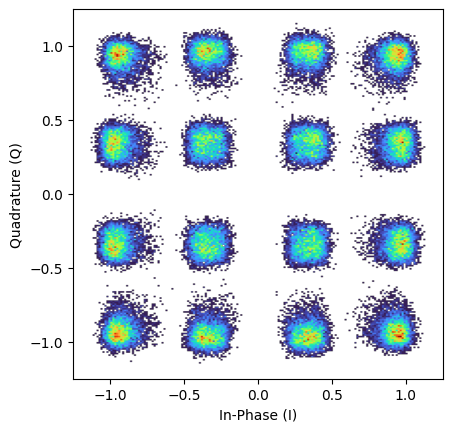


===== TX VALIDATION =====

Peak |sigTx| before PA    : 0.171459
RMS  |sigTx| before PA    : 0.062902
Nominal target peak [V]   : 3.000
Actual peak |u_drive| [V] : 2.022
Peak RF drive / Vpi       : 1.011
I voltage range / Vpi     : [-1.918 , -0.094]
Q voltage range / Vpi     : [-1.919 , -0.104]
Max |(u+Vb)/Vpi|          : 1.919
Mean optical power        : 1.0000e-03
PA gain_linear            : 17.4969
PA BO_dB                  : 5.00
PA Vsat [V]               : 1.9572
PA output RMS [V]         : 1.0132
EVM                       : 1.096 %


True
18500000000.0


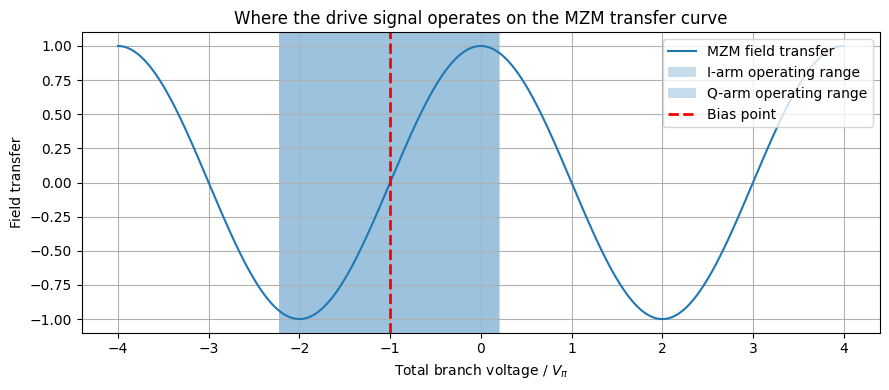

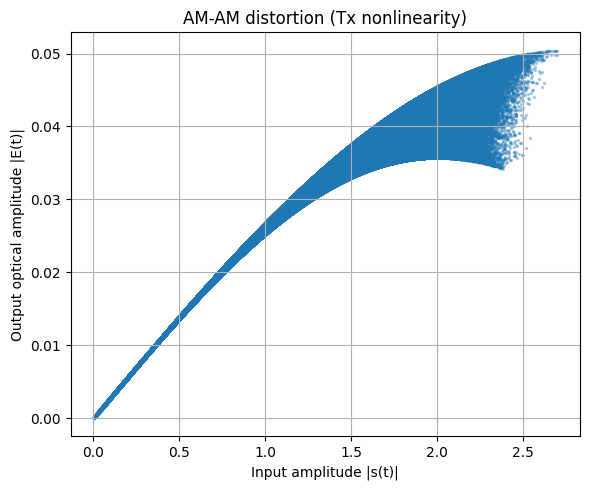

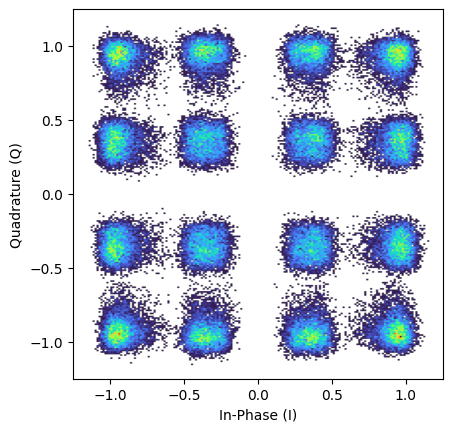


===== TX VALIDATION =====

Peak |sigTx| before PA    : 0.171459
RMS  |sigTx| before PA    : 0.062902
Nominal target peak [V]   : 4.000
Actual peak |u_drive| [V] : 2.696
Peak RF drive / Vpi       : 1.348
I voltage range / Vpi     : [-2.224 , 0.207]
Q voltage range / Vpi     : [-2.225 , 0.195]
Max |(u+Vb)/Vpi|          : 2.225
Mean optical power        : 1.0000e-03
PA gain_linear            : 23.3292
PA BO_dB                  : 5.00
PA Vsat [V]               : 2.6096
PA output RMS [V]         : 1.3509
EVM                       : 1.575 %


True
18500000000.0


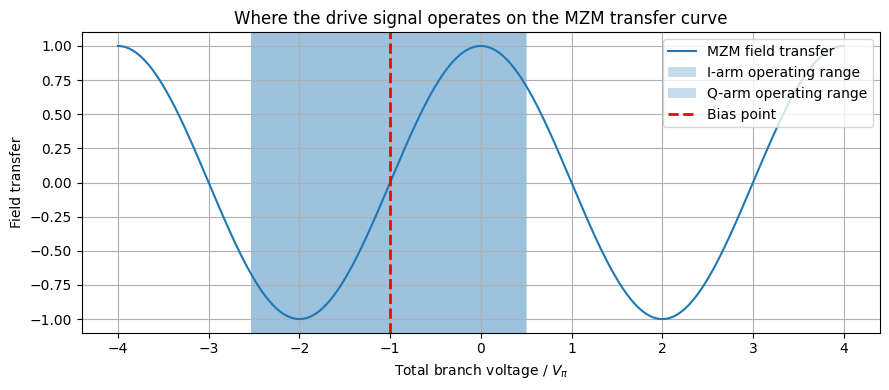

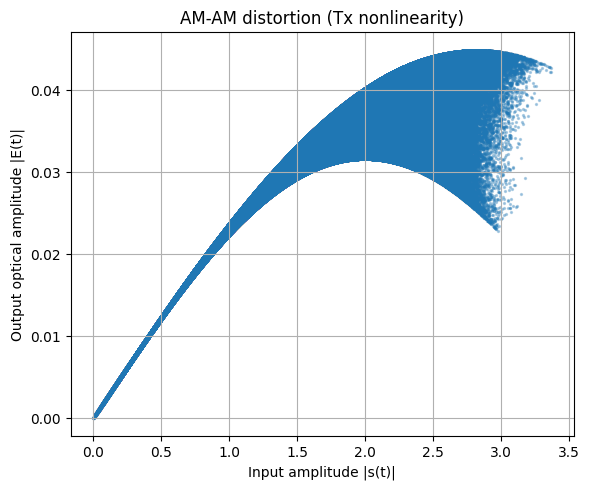

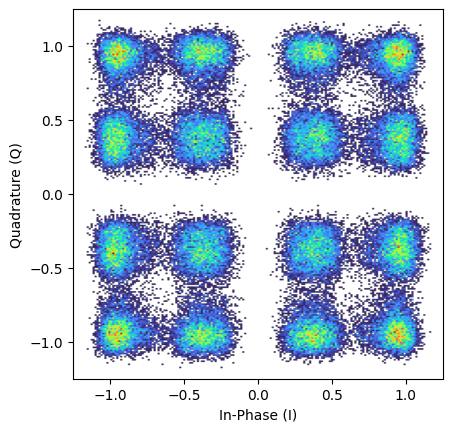


===== TX VALIDATION =====

Peak |sigTx| before PA    : 0.171459
RMS  |sigTx| before PA    : 0.062902
Nominal target peak [V]   : 5.000
Actual peak |u_drive| [V] : 3.370
Peak RF drive / Vpi       : 1.685
I voltage range / Vpi     : [-2.531 , 0.509]
Q voltage range / Vpi     : [-2.532 , 0.494]
Max |(u+Vb)/Vpi|          : 2.532
Mean optical power        : 1.0000e-03
PA gain_linear            : 29.1615
PA BO_dB                  : 5.00
PA Vsat [V]               : 3.2620
PA output RMS [V]         : 1.6887
EVM                       : 2.550 %


True
18500000000.0


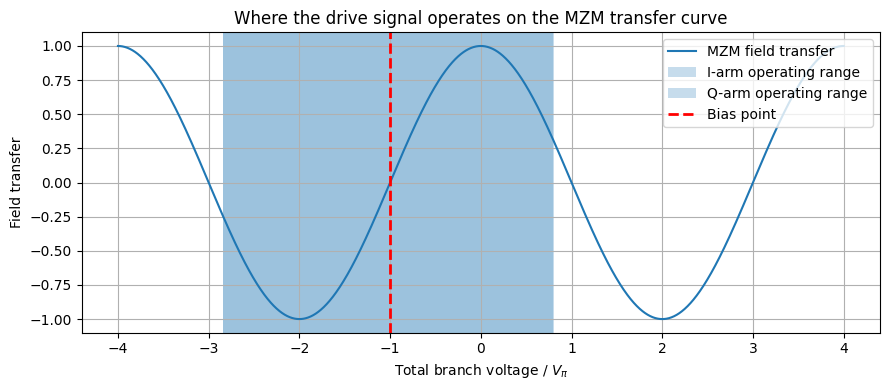

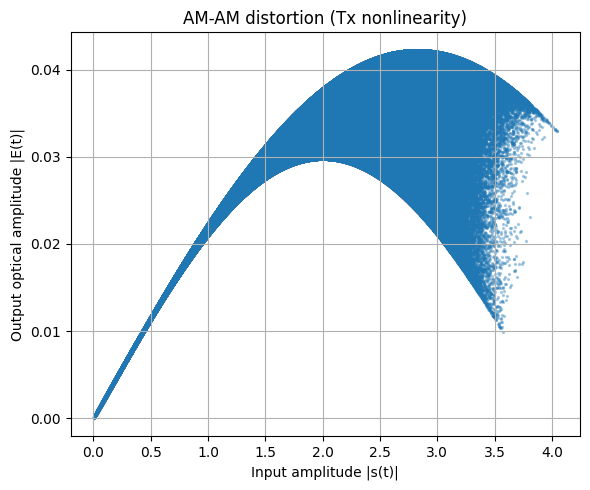

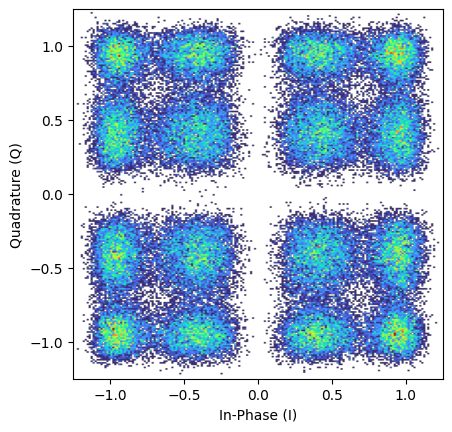


===== TX VALIDATION =====

Peak |sigTx| before PA    : 0.171459
RMS  |sigTx| before PA    : 0.062902
Nominal target peak [V]   : 6.000
Actual peak |u_drive| [V] : 4.044
Peak RF drive / Vpi       : 2.022
I voltage range / Vpi     : [-2.837 , 0.811]
Q voltage range / Vpi     : [-2.838 , 0.792]
Max |(u+Vb)/Vpi|          : 2.838
Mean optical power        : 1.0000e-03
PA gain_linear            : 34.9938
PA BO_dB                  : 5.00
PA Vsat [V]               : 3.9143
PA output RMS [V]         : 2.0264
EVM                       : 4.402 %


EVM: 0.791 %
EVM: 0.806 %
EVM: 0.842 %
EVM: 0.885 %
EVM: 0.947 %
EVM: 1.096 %
EVM: 1.575 %
EVM: 2.550 %
EVM: 4.402 %


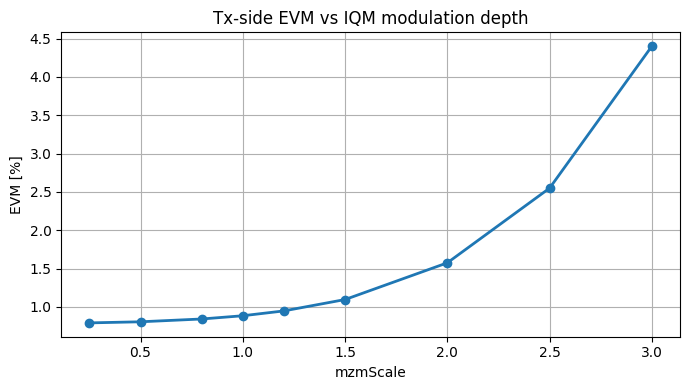

In [ ]:
symbTx = symbolSource(paramSymb)

EVM_list = []
PA_enable = True

mzmScale_list = [0.25, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3]

for mzmScale_value in tqdm(mzmScale_list, desc="mzmScale Sweep"):

    mzmScale = mzmScale_value

    u_drive, sigTx, sigTxo, matched, received, paInfo = simulate_optical_system(symbTx, paramSymb, paramPulse, paramIQM, sigLO, paramLO, paramFE, paramPD, paramRxPulse, paramDec, mzmScale, BLPF_enable)

    plot_mzm_transfer_function_and_operating_range_of_drive_signal(u_drive)

    EVM = evm_calc(symbTx, received)
    EVM_list.append(EVM)

    plot_am_am(u_drive, sigTx, sigTxo, PA_enable)
        
    discard = 5000
    # plot constellations
    pconst(received[discard:-discard])

    print_tx_metrics(sigTx, u_drive, sigTxo, paramIQM, mzmScale, EVM, paInfo)

for i in range(len(EVM_list)):
    print('EVM: %.3f %%' % (EVM_list[i][0] * 100))

EVM_vs_mzmScale_plot(mzmScale_list, EVM_list)


## Impact of the PA Butterworth Filter on PSD: Bandwidth Limitation and Non-Uniform Signal Attenuation

False
18500000000.0
True
18500000000.0


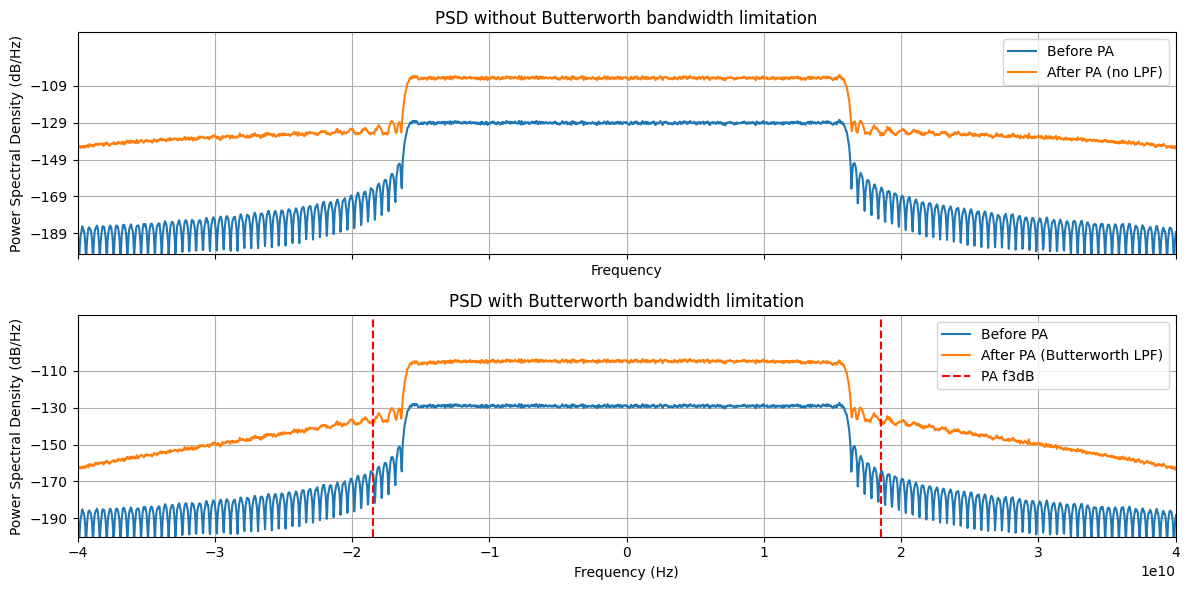

In [ ]:
mzmScale = 1.5
BLPF_enable = False
u_drive_noLPF, sigTx, sigTxo, matched, received, paInfo= simulate_optical_system(symbTx, paramSymb, paramPulse, paramIQM, sigLO, paramLO, paramFE, paramPD,paramRxPulse, paramDec, mzmScale, BLPF_enable)

BLPF_enable = True
u_drive_LPF, sigTx, sigTxo, matched, received, paInfo = simulate_optical_system(symbTx, paramSymb, paramPulse, paramIQM, sigLO, paramLO, paramFE, paramPD,paramRxPulse, paramDec, mzmScale, BLPF_enable)

fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True)

# --- WITHOUT Butterworth ---
ax[0].psd(sigTx, Fs=Fs, NFFT=16*1024, sides='twosided', label='Before PA')
ax[0].psd(u_drive_noLPF, Fs=Fs, NFFT=16*1024, sides='twosided', label='After PA (no LPF)')
ax[0].set_title("PSD without Butterworth bandwidth limitation")
ax[0].set_xlim(-40e9, 40e9)
ax[0].set_ylim(-200, -80)
ax[0].grid(True)
ax[0].legend()

# --- WITH Butterworth ---
ax[1].psd(sigTx, Fs=Fs, NFFT=16*1024, sides='twosided', label='Before PA')
ax[1].psd(u_drive_LPF, Fs=Fs, NFFT=16*1024, sides='twosided', label='After PA (Butterworth LPF)')
ax[1].axvline(PA_f3dB, color='red', linestyle='--', label='PA f3dB')
ax[1].axvline(-PA_f3dB, color='red', linestyle='--')
ax[1].set_title("PSD with Butterworth bandwidth limitation")
ax[1].set_xlim(-40e9, 40e9)
ax[1].set_ylim(-200, -80)
ax[1].grid(True)
ax[1].legend()

plt.xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()